In [69]:
from copulae.datasets import load_residuals

from copulae import ClaytonCopula, FrankCopula, GumbelCopula, GaussianCopula

from scipy.stats import rankdata

import numpy as np

import seaborn as sns

from scipy import stats

from scipy.stats import norm

import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import laplace, multivariate_normal as mvn, t

from scipy.stats import pareto, weibull_min

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

warnings.simplefilter("ignore", category=RuntimeWarning)

### Implementation of Daniel Bok's Copula packages

- each column is an unknown process
- these columns are are related i.e. have a dependency structure to one another
- our task is to learn the dependency structure so that we could simulate future events.

In [70]:
residuals = load_residuals()

residuals.head()

,A,B,C,D,E,F,G
0,0.730967,0.530860,0.287320,1.193049,0.019040,1.100507,0.278214
1,2.067853,-1.181313,-2.546173,0.381538,-0.038734,0.269874,-0.603940
2,-2.181835,0.380326,0.928632,-0.316861,0.106473,-0.324854,-0.447824
3,0.445040,0.734531,-0.133299,-0.374091,0.173616,-0.319402,-0.775106
4,0.296363,3.024053,0.815791,1.168521,0.134044,1.110424,1.705190


In [75]:
# ndim = number of columns or residuals that are related

_, ndim = residuals.shape

g_cop = GaussianCopula(dim=ndim)  # initializing the copula

g_cop.fit(residuals)  # fit the copula to the data

                A           B           C           D           E           F  \
count  394.000000  394.000000  394.000000  394.000000  394.000000  394.000000   
mean     0.500000    0.500000    0.500000    0.500000    0.500000    0.500000   
std      0.288309    0.288309    0.288309    0.288309    0.288309    0.288309   
min      0.002532    0.002532    0.002532    0.002532    0.002532    0.002532   
25%      0.251266    0.251266    0.251266    0.251266    0.251266    0.251266   
50%      0.500000    0.500000    0.500000    0.500000    0.500000    0.500000   
75%      0.748734    0.748734    0.748734    0.748734    0.748734    0.748734   
max      0.997468    0.997468    0.997468    0.997468    0.997468    0.997468   

                G  
count  394.000000  
mean     0.500000  
std      0.288309  
min      0.002532  
25%      0.251266  
50%      0.500000  
75%      0.748734  
max      0.997468  


In [ ]:
# generate random uniform variables to test their likelihood of occurring under the copula 

random_matrix = np.random.uniform(0, 1, size=(2, 7))

pdf = g_cop.pdf(random_matrix)  # length 2 ndarray

cdf = g_cop.cdf(random_matrix)  # length 2 ndarray 

In [105]:
# Akaike Information Criterion (AIC)

data = ## uniform marginals in [0,1]

def compute_aic(cop, data):
    
    """Compute AIC = -2*log-likelihood + 2*k"""
    
    ll = cop.log_lik(data)
    
    k = 1  # number of parameters for Archimedean copulas (Clayton, Frank, Gumbel); 1 param
    
    return -2 * ll + 2 * k

# fit various copulas

copulas = {
    
    "clayton": ClaytonCopula(dim=2).fit(data),
    
    "frank": FrankCopula(dim=2).fit(data),
    
    "gumbel": GumbelCopula(dim=2).fit(data),
    
    "gaussian": GaussianCopula(dim=2).fit(data),
}

/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/copulae/archimedean/gumbel.py:161: UserWarning: For the Gumbel copula, tau must be >= 0. Replacing negative values by 0.
  warnings.warn(warning_message)


## Example: What is the joint distribution between river level height and probability of flooding?

- These two variables are non-normally distributed and correlated 
- For the probability distribution of the maximum level of the river we can look to Extreme Value Theory which tells us that maximums are Gumbel distributed
- How many times flooding occured will be modeled according to a Beta distribution

In [62]:
# initialize a multivariate normal with a given correlation structure

mvnorm = stats.multivariate_normal(mean=[0, 0], cov=[[1., 0.5], 
                                                     [0.5, 1.]])

# generate random samples from mvnorm

x = mvnorm.rvs(100000)

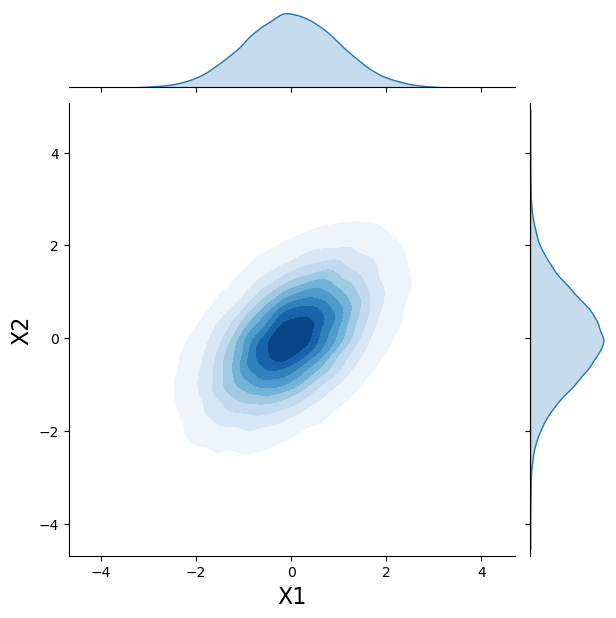

In [64]:
g = sns.JointGrid(x=x[:, 0], y=x[:, 1])

sns.kdeplot(x=x[:, 0], y=x[:, 1], fill=True, cmap="Blues", ax=g.ax_joint)

sns.kdeplot(x=x[:, 0], fill=True, ax=g.ax_marg_x)

sns.kdeplot(y=x[:, 1], fill=True, ax=g.ax_marg_y)

g.set_axis_labels("X1", "X2", fontsize=16)

### uniform-ify the marginals using CDF

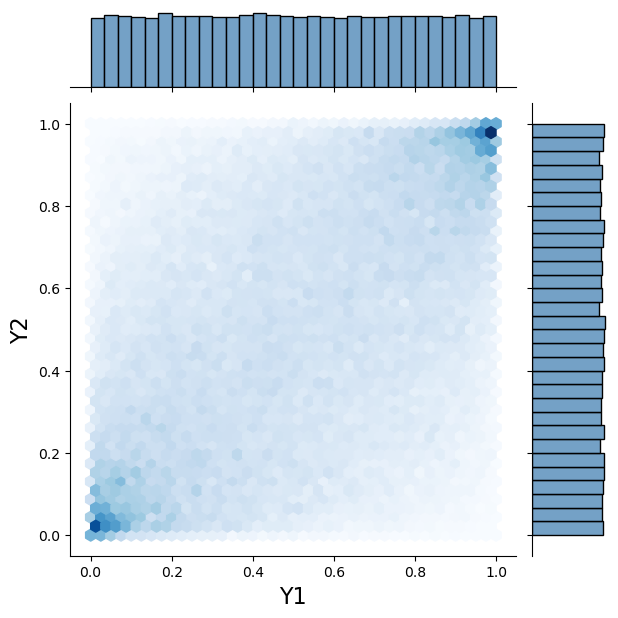

In [66]:
norm = stats.norm()

x_unif = norm.cdf(x)

g = sns.JointGrid(x=x_unif[:, 0], y=x_unif[:, 1])

g.ax_joint.hexbin(x_unif[:, 0], x_unif[:, 1], gridsize=40, cmap="Blues")

sns.histplot(x=x_unif[:, 0], bins=30, kde=False, ax=g.ax_marg_x, color="steelblue")

sns.histplot(y=x_unif[:, 1], bins=30, kde=False, ax=g.ax_marg_y, color="steelblue")

g.set_axis_labels("Y1", "Y2", fontsize=16)

### transform marginals to gumbel and beta 

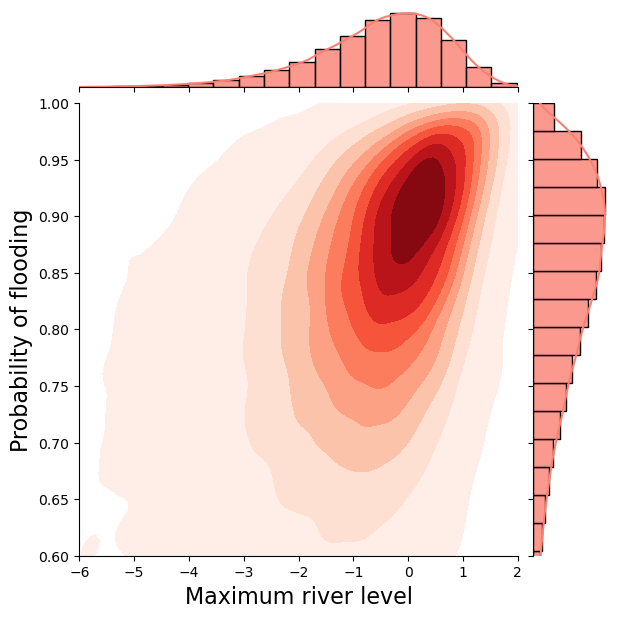

In [67]:
# define marginals

m1 = stats.gumbel_l()

m2 = stats.beta(a=10, b=2)

# transform copula sample to marginals

x1_trans = m1.ppf(x_unif[:, 0])

x2_trans = m2.ppf(x_unif[:, 1])

# create JointGrid

g = sns.JointGrid(x=x1_trans, y=x2_trans, xlim=(-6, 2), ylim=(0.6, 1.0))

# filled KDE in joint plot

sns.kdeplot(x=x1_trans, y=x2_trans, fill=True, cmap="Reds", ax=g.ax_joint, thresh=0.01)

# marginals (filled histograms)

sns.histplot(x=x1_trans, bins=30, kde=True, stat="density", ax=g.ax_marg_x, color="salmon", alpha=0.8)

sns.histplot(y=x2_trans, bins=30, kde=True, stat="density", ax=g.ax_marg_y, color="salmon", alpha=0.8)

g.set_axis_labels("Maximum river level", "Probability of flooding", fontsize=16)

### compared to joint distribution without correlations

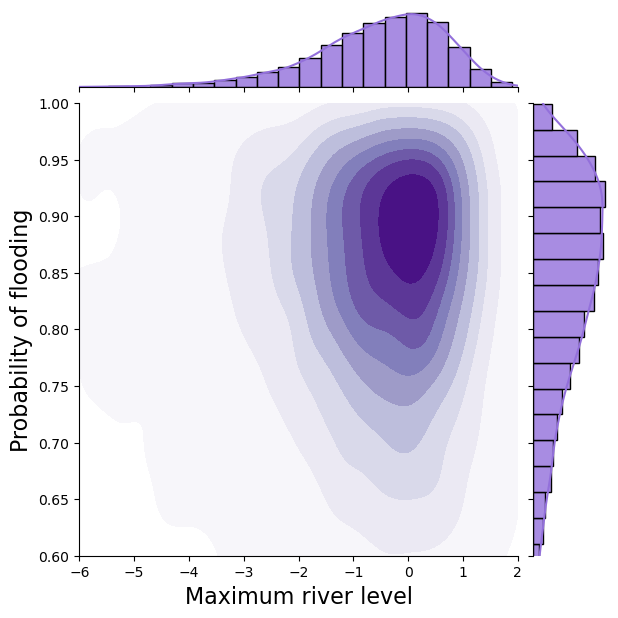

In [68]:
# sample from marginals independently

m1 = stats.gumbel_l()

m2 = stats.beta(a=10, b=2)

x1 = m1.rvs(10000)

x2 = m2.rvs(10000)

# create JointGrid

g = sns.JointGrid(x=x1, y=x2, xlim=(-6, 2), ylim=(0.6, 1.0))

# filled 2D KDE for joint distribution

sns.kdeplot(x=x1, y=x2, fill=True, cmap="Purples", ax=g.ax_joint, thresh=0.01)

# marginal plots (filled histograms with optional KDE)

sns.histplot(x=x1, bins=30, kde=True, stat="density", color="mediumpurple", ax=g.ax_marg_x, alpha=0.8)

sns.histplot(y=x2, bins=30, kde=True, stat="density", color="mediumpurple", ax=g.ax_marg_y, alpha=0.8)

g.set_axis_labels("Maximum river level", "Probability of flooding", fontsize=16)


## HDW synthetic example

In [87]:
from copulae import StudentCopula

In [88]:
np.random.seed(42)

# Step 1: simulate multivariate normal for dependence
n_samples = 5000

corr = np.array([
    [1.0, -0.7,  0.4],   # Temp-RH, Temp-Wind
    [-0.7, 1.0, -0.3],   # RH-Wind
    [0.4, -0.3,  1.0]
])

mvnorm = stats.multivariate_normal(mean=[0, 0, 0], cov=corr)

z = mvnorm.rvs(size=n_samples)

# convert to uniform marginals via CDF (Gaussian copula base)

u = stats.norm.cdf(z)

# apply desired marginals

temp = stats.gumbel_r(loc=30, scale=4).ppf(u[:, 0])        # Temp

rh = stats.beta(a=2, b=5, loc=0, scale=100).ppf(u[:, 1])   # RH 

wind = stats.weibull_min(c=2, scale=8).ppf(u[:, 2])        # Wind

# build dataframe

df = pd.DataFrame({
    "temp_C": temp,
    "rh_pct": rh,
    "wind_mps": wind
})

In [89]:
# fit marginals

marg_temp = stats.gumbel_r.fit(temp)

marg_rh = stats.beta.fit(rh, floc=0, fscale=100)

marg_wind = stats.weibull_min.fit(wind)

# transform to uniforms

u_temp = stats.gumbel_r(*marg_temp).cdf(temp)

u_rh = stats.beta(*marg_rh).cdf(rh)

u_wind = stats.weibull_min(*marg_wind).cdf(wind)

U = np.column_stack([u_temp, u_rh, u_wind])

# Fit Student Copula

cop = StudentCopula(dim=3)

cop.fit(U)

In [91]:
# Sample future weather dependence

U_future = cop.random(10000)  # uniform samples with dependence

# Map back to physical space using inverse marginals

T_future = stats.gumbel_r(*marg_temp).ppf(U_future[:, 0])

RH_future = stats.beta(*marg_rh).ppf(U_future[:, 1])

W_future = stats.weibull_min(*marg_wind).ppf(U_future[:, 2])

future_df = pd.DataFrame({
    "temp_C": T_future,
    "rh_pct": RH_future,
    "wind_mps": W_future
})

In [92]:
extreme_days = (
    (future_df["temp_C"] > 38) &
    (future_df["rh_pct"] < 25) &
    (future_df["wind_mps"] > 12)
)

joint_extreme_prob = extreme_days.mean()

print(f"Estimated probability of hot, dry, windy fire weather: {joint_extreme_prob:.4f}")

Estimated probability of hot, dry, windy fire weather: 0.0306


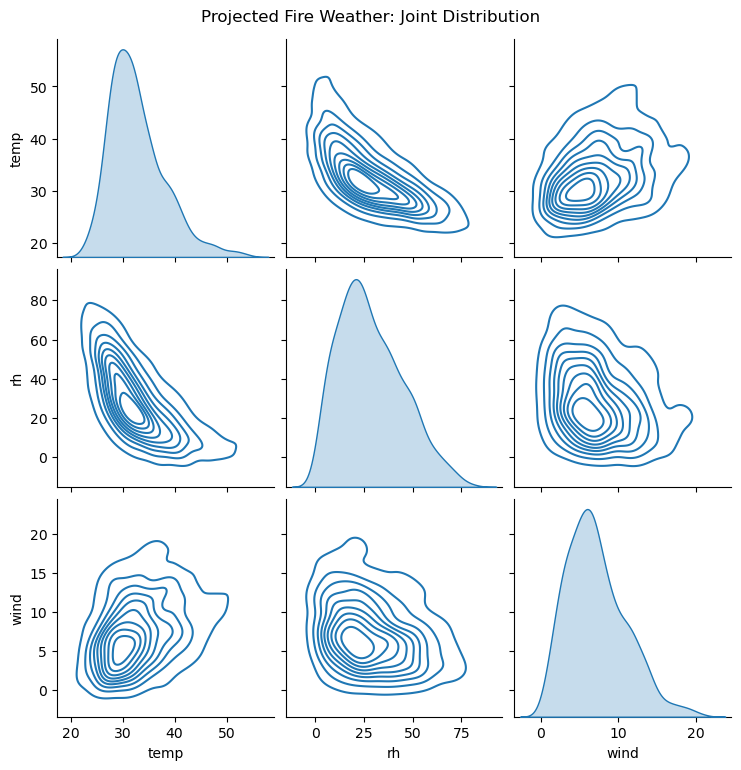

In [93]:
plot_df = future_df[["temp_C", "rh_pct", "wind_mps"]].rename(columns={
    "temp_C": "temp",
    "rh_pct": "rh",
    "wind_mps": "wind"})

sns.pairplot(plot_df.sample(1000), kind="kde", diag_kind="kde")

plt.suptitle("Projected Fire Weather: Joint Distribution", y=1.02)

plt.show()

### How to check for Copula goodness of fit, could use AIC
#### generally choose the lowest AIC for best fit

In [ ]:
def pseudo_obs(data):
    
    """Convert data to pseudo-observations (uniform marginals in [0,1])"""
    
    ranks = np.apply_along_axis(rankdata, 0, data)
    
    return (ranks - 1) / data.shape[0]

# Akaike Information Criterion (AIC)

def compute_aic(cop, data):
    
    """Compute AIC = -2*log-likelihood + 2*k"""
    
    ll = cop.log_lik(data)
    
    k = 1  # number of parameters for Archimedean copulas (Clayton, Frank, Gumbel); 1 param
    
    return -2 * ll + 2 * k

# example data (should be pseudo-observations in [0, 1])

data = pseudo_obs(np.random.normal(size=(500, 2)))

# fit various copulas

copulas = {
    
    "clayton": ClaytonCopula(dim=2).fit(data),
    
    "frank": FrankCopula(dim=2).fit(data),
    
    "gumbel": GumbelCopula(dim=2).fit(data),
    
    "gaussian": GaussianCopula(dim=2).fit(data),
}

# Compare AICs

for name, cop in copulas.items():
    
    aic = compute_aic(cop, data)
    
    print(f"{name.capitalize()} AIC: {aic:.2f}")